In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
pd.options.mode.use_inf_as_na = True

import itertools
import ffn
import pypfopt
import matplotlib.pyplot as plt

from itertools import chain
from datetime import date

from pypfopt import expected_returns
from pypfopt import HRPOpt, EfficientFrontier, objective_functions # Hierarchical Parity Optimization 
from pypfopt import plotting


import pyfolio as pf
import os 
#import matplotlib
#import matplotlib.pyplot as plt
#matplotlib.use('Agg')

In [6]:
df = pd.read_pickle("/Users/safishajjouz/GitHub/myPortfolioManagement/files/myfunds_prices.pkl")  
df

,Close,fund,ISIN,yahoo_ticker,short_name,myfunds,abs_retunrs
Date,,,,,,,
2009-06-24,99.096,Vanguard Global Bond Index Fund GBP Hedged Acc...,IE00B50W2R13,0P0000KM24.L,Global Bond,F,F
2009-06-25,99.946,Vanguard Global Bond Index Fund GBP Hedged Acc...,IE00B50W2R13,0P0000KM24.L,Global Bond,F,F
2009-06-26,99.419,Vanguard Global Bond Index Fund GBP Hedged Acc...,IE00B50W2R13,0P0000KM24.L,Global Bond,F,F
2009-06-29,99.253,Vanguard Global Bond Index Fund GBP Hedged Acc...,IE00B50W2R13,0P0000KM24.L,Global Bond,F,F
2009-06-30,99.493,Vanguard Global Bond Index Fund GBP Hedged Acc...,IE00B50W2R13,0P0000KM24.L,Global Bond,F,F
...,...,...,...,...,...,...,...
2021-10-06,25.730,Nordea 1 - Global Climate and Environment Fund...,LU0841585341,NaN,Nordea Climate,F,F
2021-10-07,26.260,Nordea 1 - Global Climate and Environment Fund...,LU0841585341,NaN,Nordea Climate,F,F
2021-10-08,26.080,Nordea 1 - Global Climate and Environment Fund...,LU0841585341,NaN,Nordea Climate,F,F


In [7]:
df.to_excel("/Users/safishajjouz/GitHub/myPortfolioManagement/files/myfunds_prices.xlsx", index=True)

In [3]:
# set working directory 
os.chdir("/Users/safishajjouz/GitHub/myPortfolioManagement/files")

In [6]:
# this is the dataframe with my assets in long format 
df = pd.read_excel("/Users/safishajjouz/GitHub/myPortfolioManagement/files/myfunds_prices.xlsx", engine='openpyxl')
df[["fund","fund"]].drop_duplicates()

,fund,fund
0,Vanguard Ftse Dev World Ex Uk Equity Index Acc,Vanguard Ftse Dev World Ex Uk Equity Index Acc
990,Baillie Gifford American Fund B Accumulation,Baillie Gifford American Fund B Accumulation
1975,Baillie Gifford Positive Change Fund B Accumul...,Baillie Gifford Positive Change Fund B Accumul...
2811,Baillie Gifford Global Income Growth Fund B Ac...,Baillie Gifford Global Income Growth Fund B Ac...
3793,Baillie Gifford Pacific B Acc,Baillie Gifford Pacific B Acc
4461,Fidelity Funds - Global Technology Fund W-acc-gbp,Fidelity Funds - Global Technology Fund W-acc-gbp
5466,Baillie Gifford European Fund B Accumulation,Baillie Gifford European Fund B Accumulation


In [9]:
# Clean database 
df_cleaned = df.pivot_table(index=["Date"], 
                    columns='fund', 
                    values='adjclose')

# main data frame [this would be the starting point of the analysis]
slicde_date = "2019/05/01"


df_cleaned = df_cleaned[df_cleaned.index >= slicde_date]
df_cleaned.index = pd.to_datetime(df_cleaned.index, format='%Y/%m/%d')

# full Dataframe with Returns Cleaned
rets_all_funds = expected_returns.returns_from_prices(df_cleaned.interpolate(method = "time")) 
rets_all_funds

fund,Baillie Gifford American Fund B Accumulation,Baillie Gifford European Fund B Accumulation,Baillie Gifford Global Income Growth Fund B Accumulation,Baillie Gifford Pacific B Acc,Baillie Gifford Positive Change Fund B Accumulation,Fidelity Funds - Global Technology Fund W-acc-gbp,Vanguard Ftse Dev World Ex Uk Equity Index Acc
Date,,,,,,,
2019-05-02,-0.004860,-0.011168,-0.006831,-0.000955,-0.008490,-0.011072,0.000250
2019-05-03,0.004884,0.003294,0.001376,0.003959,0.004893,0.001919,0.000776
2019-05-06,0.008202,-0.003870,-0.006696,-0.020703,-0.002282,-0.007663,-0.010079
2019-05-07,0.002712,-0.001295,-0.002247,-0.007047,-0.000763,-0.012870,-0.003394
2019-05-08,-0.020433,-0.008487,-0.006930,-0.011607,-0.009768,0.000652,0.002135
...,...,...,...,...,...,...,...
2021-12-06,-0.032928,-0.019445,-0.000468,-0.019663,-0.026894,0.035442,0.008159
2021-12-07,0.009429,0.038604,0.021983,0.014327,0.013819,0.011410,0.021377
2021-12-08,0.034769,0.018330,0.013730,0.016243,0.026737,-0.003167,0.005391


<AxesSubplot:xlabel='Date'>

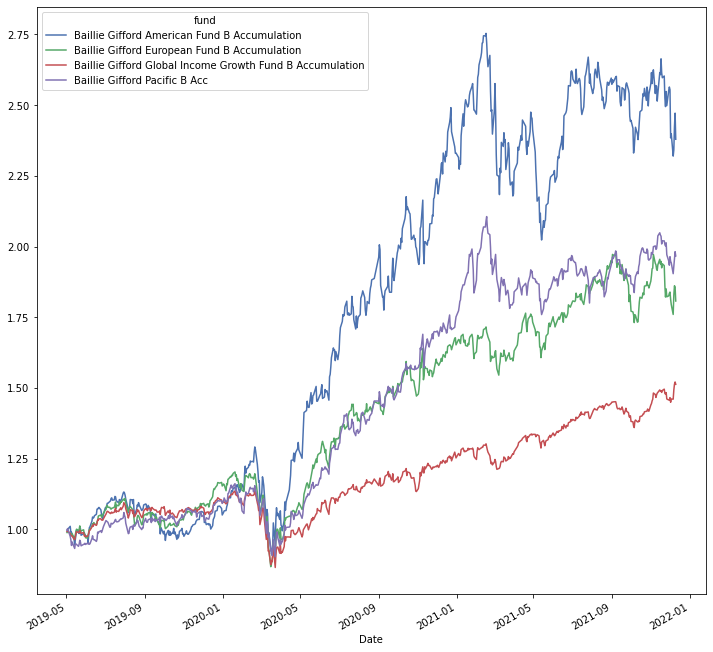

In [10]:
rets_dummy = rets_all_funds[rets_all_funds.index>="2019-05-01"]
pf.timeseries.cum_returns(rets_dummy.iloc[:,0:4], starting_value=1).plot(figsize=(12,12))

In [11]:
price_index = ffn.core.to_price_index(rets_dummy, start=100)
perf = price_index.iloc[:,0:4].calc_stats()
print(perf.display())

Stat                 Baillie Gifford American Fund B Accumulation    Baillie Gifford European Fund B Accumulation    Baillie Gifford Global Income Growth Fund B Accumulation    Baillie Gifford Pacific B Acc
-------------------  ----------------------------------------------  ----------------------------------------------  ----------------------------------------------------------  -------------------------------
Start                2019-05-02                                      2019-05-02                                      2019-05-02                                                  2019-05-02
End                  2021-12-10                                      2021-12-10                                      2021-12-10                                                  2021-12-10
Risk-free rate       0.00%                                           0.00%                                           0.00%                                                       0.00%

Total Return         139

In [12]:
# check some basic perfomance stats for each asset 
df_stats = ffn.core.GroupStats(df_cleaned[df_cleaned.index>="2019-05-01"]).stats
keep_index = ["total_return", "max_drawdown", "calmar", "ytd", 
              "three_month", "six_month", 'one_year', 'three_year',
              'monthly_sortino']

In [13]:
df_stats[df_stats.index.isin(keep_index)].transpose().sort_values(by=['total_return'], ascending= False)

,total_return,max_drawdown,calmar,three_month,six_month,ytd,one_year,three_year,monthly_sortino
Baillie Gifford American Fund B Accumulation,1.379101,-0.293509,1.340752,-0.073794,0.028902,0.020855,0.054389,0.393523,3.61277
Baillie Gifford Positive Change Fund B Accumulation,1.321407,-0.235888,1.612996,-0.108108,0.071969,0.119953,0.136242,0.380486,5.320881
Fidelity Funds - Global Technology Fund W-acc-gbp,0.978488,-0.240419,1.241741,0.056597,0.12119,0.255067,0.259617,0.298538,6.13541
Baillie Gifford Pacific B Acc,0.966721,-0.222235,1.330013,0.006983,0.039654,0.123053,0.151757,0.295576,4.369972
Baillie Gifford European Fund B Accumulation,0.807352,-0.278422,0.913469,-0.070813,0.03243,0.093776,0.123193,0.25433,3.579208
Vanguard Ftse Dev World Ex Uk Equity Index Acc,0.537098,-0.255941,0.699031,0.071502,0.137109,0.235773,0.230149,0.178911,2.530249
Baillie Gifford Global Income Growth Fund B Accumulation,0.512978,-0.238582,0.720061,0.060824,0.122087,0.207743,0.217702,0.171793,2.753926


In [15]:
rets_all = rets_all_funds
rets_all

fund,Baillie Gifford American Fund B Accumulation,Baillie Gifford European Fund B Accumulation,Baillie Gifford Global Income Growth Fund B Accumulation,Baillie Gifford Pacific B Acc,Baillie Gifford Positive Change Fund B Accumulation,Fidelity Funds - Global Technology Fund W-acc-gbp,Vanguard Ftse Dev World Ex Uk Equity Index Acc
Date,,,,,,,
2019-05-02,-0.004860,-0.011168,-0.006831,-0.000955,-0.008490,-0.011072,0.000250
2019-05-03,0.004884,0.003294,0.001376,0.003959,0.004893,0.001919,0.000776
2019-05-06,0.008202,-0.003870,-0.006696,-0.020703,-0.002282,-0.007663,-0.010079
2019-05-07,0.002712,-0.001295,-0.002247,-0.007047,-0.000763,-0.012870,-0.003394
2019-05-08,-0.020433,-0.008487,-0.006930,-0.011607,-0.009768,0.000652,0.002135
...,...,...,...,...,...,...,...
2021-12-06,-0.032928,-0.019445,-0.000468,-0.019663,-0.026894,0.035442,0.008159
2021-12-07,0.009429,0.038604,0.021983,0.014327,0.013819,0.011410,0.021377
2021-12-08,0.034769,0.018330,0.013730,0.016243,0.026737,-0.003167,0.005391


In [17]:
# Quick Clustering 

import ffn
rets_all.calc_ftca(threshold=0.8)

{1: ['Baillie Gifford Global Income Growth Fund B Accumulation',
  'Baillie Gifford European Fund B Accumulation'],
 2: ['Vanguard Ftse Dev World Ex Uk Equity Index Acc'],
 3: ['Baillie Gifford Positive Change Fund B Accumulation',
  'Baillie Gifford American Fund B Accumulation'],
 4: ['Fidelity Funds - Global Technology Fund W-acc-gbp'],
 5: ['Baillie Gifford Pacific B Acc']}

In [18]:
rets_all[rets_all.index>="2020-11-01"].calc_ftca(threshold=0.8)

{1: ['Baillie Gifford Positive Change Fund B Accumulation',
  'Baillie Gifford American Fund B Accumulation'],
 2: ['Vanguard Ftse Dev World Ex Uk Equity Index Acc'],
 3: ['Baillie Gifford Global Income Growth Fund B Accumulation'],
 4: ['Fidelity Funds - Global Technology Fund W-acc-gbp'],
 5: ['Baillie Gifford Pacific B Acc'],
 6: ['Baillie Gifford European Fund B Accumulation']}

In [19]:
# Train Period  
# ===========
training_start_date = pd.to_datetime("2019/05/01", format='%Y/%m/%d') 
training_end_date = pd.to_datetime("2021/03/01", format='%Y/%m/%d')
rets_training = rets_all[(rets_all.index>=training_start_date) & (rets_all.index<=training_end_date)]

In [20]:
# Portfolio Optimisation  - HRP 
# train solver 
hrp = HRPOpt(rets_training)
hrp.optimize()
cleaned_weights_hrp = hrp.clean_weights()
cleaned_weights_hrp = pd.DataFrame(cleaned_weights_hrp , index=[0])
cleaned_weights_hrp = pd.melt(cleaned_weights_hrp, var_name = 'fund', value_name = 'weight_hrp')


In [21]:
hrp.portfolio_performance()

(0.29062723040303823, 0.18452302793123934, 1.4666312028213884)

In [22]:
cleaned_weights_hrp["amount"] = cleaned_weights_hrp["weight_hrp"]*30000
cleaned_weights_hrp

,fund,weight_hrp,amount
0,Baillie Gifford American Fund B Accumulation,0.05817,1745.1
1,Baillie Gifford European Fund B Accumulation,0.12405,3721.5
2,Baillie Gifford Global Income Growth Fund B Ac...,0.18605,5581.5
3,Baillie Gifford Pacific B Acc,0.21073,6321.9
4,Baillie Gifford Positive Change Fund B Accumul...,0.10810,3243.0
5,Fidelity Funds - Global Technology Fund W-acc-gbp,0.15313,4593.9
6,Vanguard Ftse Dev World Ex Uk Equity Index Acc,0.15977,4793.1


<AxesSubplot:>

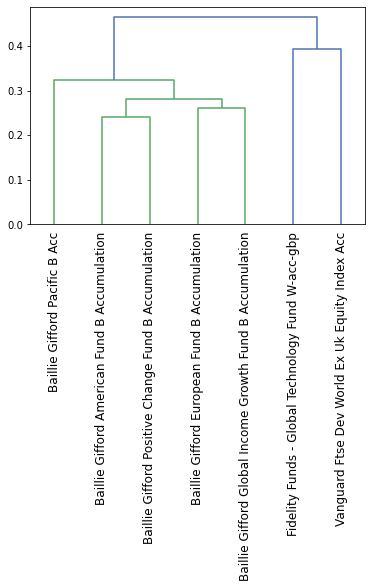

In [23]:
plotting.plot_dendrogram(hrp)

In [24]:
# risk parity 
pd.Series.to_frame(ffn.core.calc_erc_weights(rets_training, initial_weights=None, 
                          risk_weights=None, 
                          covar_method='ledoit-wolf', 
                                             risk_parity_method='ccd'), 
                   name = "weight_rp")

,weight_rp
fund,
Baillie Gifford American Fund B Accumulation,0.104952
Baillie Gifford European Fund B Accumulation,0.130122
Baillie Gifford Global Income Growth Fund B Accumulation,0.154785
Baillie Gifford Pacific B Acc,0.138147
Baillie Gifford Positive Change Fund B Accumulation,0.129892
Fidelity Funds - Global Technology Fund W-acc-gbp,0.162064
Vanguard Ftse Dev World Ex Uk Equity Index Acc,0.180037


In [25]:
pd.Series.to_frame(ffn.core.calc_inv_vol_weights(rets_training), name = "weight_iv")

,weight_iv
fund,
Baillie Gifford American Fund B Accumulation,0.103111
Baillie Gifford European Fund B Accumulation,0.139840
Baillie Gifford Global Income Growth Fund B Accumulation,0.171257
Baillie Gifford Pacific B Acc,0.144541
Baillie Gifford Positive Change Fund B Accumulation,0.140557
Fidelity Funds - Global Technology Fund W-acc-gbp,0.148752
Vanguard Ftse Dev World Ex Uk Equity Index Acc,0.151942


In [26]:
#minimum volatility 
S = pypfopt.risk_models.risk_matrix(rets_training, method= "ledoit_wolf", returns_data = True)
mu = expected_returns.mean_historical_return(rets_training)

ef = EfficientFrontier(mu, S)
ef.add_objective(objective_functions.L2_reg, gamma=0.9)
ef.min_volatility()
cleaned_weights = ef.clean_weights()
cleaned_weights = pd.DataFrame(cleaned_weights , index=[0])
cleaned_weights = pd.melt(cleaned_weights, var_name = 'fund', value_name = 'weight_min_vol')
cleaned_weights




,fund,weight_min_vol
0,Baillie Gifford American Fund B Accumulation,0.12844
1,Baillie Gifford European Fund B Accumulation,0.13991
2,Baillie Gifford Global Income Growth Fund B Ac...,0.14683
3,Baillie Gifford Pacific B Acc,0.14241
4,Baillie Gifford Positive Change Fund B Accumul...,0.13933
5,Fidelity Funds - Global Technology Fund W-acc-gbp,0.14962
6,Vanguard Ftse Dev World Ex Uk Equity Index Acc,0.15346


In [27]:
df_portfolios = cleaned_weights.merge(cleaned_weights_hrp, how = "left")

In [28]:
#calculate portfolio returns 
def cul_port_returns(df_returns,df_weights, portfolio_name = None):
    '''
    df_returns: a wide DataFrame series with assets returns 
    df_wegiths: a long Datafrane with Fund names in the first colum 
                and weight in the other 
    '''
    weight_name = df_weights.columns[1]
    df_weights = df_weights.sort_values("fund")
    funds = list(df_weights["fund"])
    df_returns = df_returns[funds]
    df_returns =  df_returns[sorted(df_returns.columns)]
    weights = pd.Series.to_numpy(df_weights[weight_name])
    port_returns = df_returns.fillna(0).dot(weights)  # this is a workaround due to NAs 
    if portfolio_name is None: 
        port_returns = pd.Series(port_returns, name = "portfolio")
    else:
        port_returns = pd.Series(port_returns, name = portfolio_name)
    port_returns = pd.DataFrame(port_returns)
    return port_returns

In [29]:
rets_portf_min_vol = cul_port_returns(rets_all,df_portfolios[["fund","weight_min_vol"]], portfolio_name= "portfolio_min_vol")
rets_portf_hrp = cul_port_returns(rets_all,df_portfolios[["fund","weight_hrp"]], portfolio_name= "portfolio_HRP")
rets_portf = rets_portf_hrp.merge(rets_portf_min_vol, how = "left", left_index = True, right_index= True)
rets_portf

,portfolio_HRP,portfolio_min_vol
Date,,
2019-05-02,-0.005714,-0.006127
2019-05-03,0.002730,0.002942
2019-05-06,-0.008642,-0.006431
2019-05-07,-0.004501,-0.003719
2019-05-08,-0.006592,-0.007418
...,...,...
2021-12-06,-0.004735,-0.007011
2021-12-07,0.019103,0.018793
2021-12-08,0.013540,0.015438


In [30]:
rets = rets_all.join(rets_portf)

In [35]:
benchmark = ['Vanguard Ftse Dev World Ex Uk Equity Index Acc']
df_bench = df[df["fund"].isin(benchmark)].drop_duplicates()
df_bench

,Date,open,high,low,adjclose,currency,fund
0,2018-01-02,330.54,330.54,330.54,330.54,GBP,Vanguard Ftse Dev World Ex Uk Equity Index Acc
1,2018-01-03,333.82,333.82,333.82,333.82,GBP,Vanguard Ftse Dev World Ex Uk Equity Index Acc
2,2018-01-04,335.58,335.58,335.58,335.58,GBP,Vanguard Ftse Dev World Ex Uk Equity Index Acc
3,2018-01-05,337.56,337.56,337.56,337.56,GBP,Vanguard Ftse Dev World Ex Uk Equity Index Acc
4,2018-01-08,337.48,337.48,337.48,337.48,GBP,Vanguard Ftse Dev World Ex Uk Equity Index Acc
...,...,...,...,...,...,...,...
985,2021-12-06,541.23,541.23,541.23,541.23,GBP,Vanguard Ftse Dev World Ex Uk Equity Index Acc
986,2021-12-07,552.80,552.80,552.80,552.80,GBP,Vanguard Ftse Dev World Ex Uk Equity Index Acc
987,2021-12-08,555.78,555.78,555.78,555.78,GBP,Vanguard Ftse Dev World Ex Uk Equity Index Acc
988,2021-12-09,552.35,552.35,552.35,552.35,GBP,Vanguard Ftse Dev World Ex Uk Equity Index Acc


In [36]:
rets_dummy = rets[rets.index >= "2021-03-01"]
rets_dummy = rets_dummy[benchmark + ["portfolio_min_vol",'portfolio_HRP']]

<AxesSubplot:xlabel='Date'>

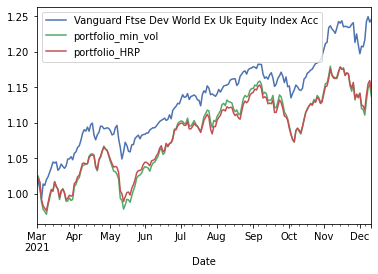

In [37]:
pf.timeseries.cum_returns(rets_dummy, starting_value=1).plot()

In [39]:
rets.index = rets.index.tz_localize('utc')

In [51]:
rets[["portfolio_HRP"]].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 672 entries, 2019-05-02 00:00:00+00:00 to 2021-12-10 00:00:00+00:00
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   portfolio_HRP  672 non-null    float64
dtypes: float64(1)
memory usage: 26.7 KB


### Simple Deterministic Backtesting

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,23.62,2020-02-20,2020-03-16,2020-05-25,68
1,8.88,2021-02-16,2021-03-09,2021-06-23,92
2,6.95,2021-09-07,2021-10-06,2021-11-04,43
3,6.09,2019-07-30,2019-08-27,2019-11-27,87
4,5.59,2020-10-14,2020-10-30,2020-11-09,19


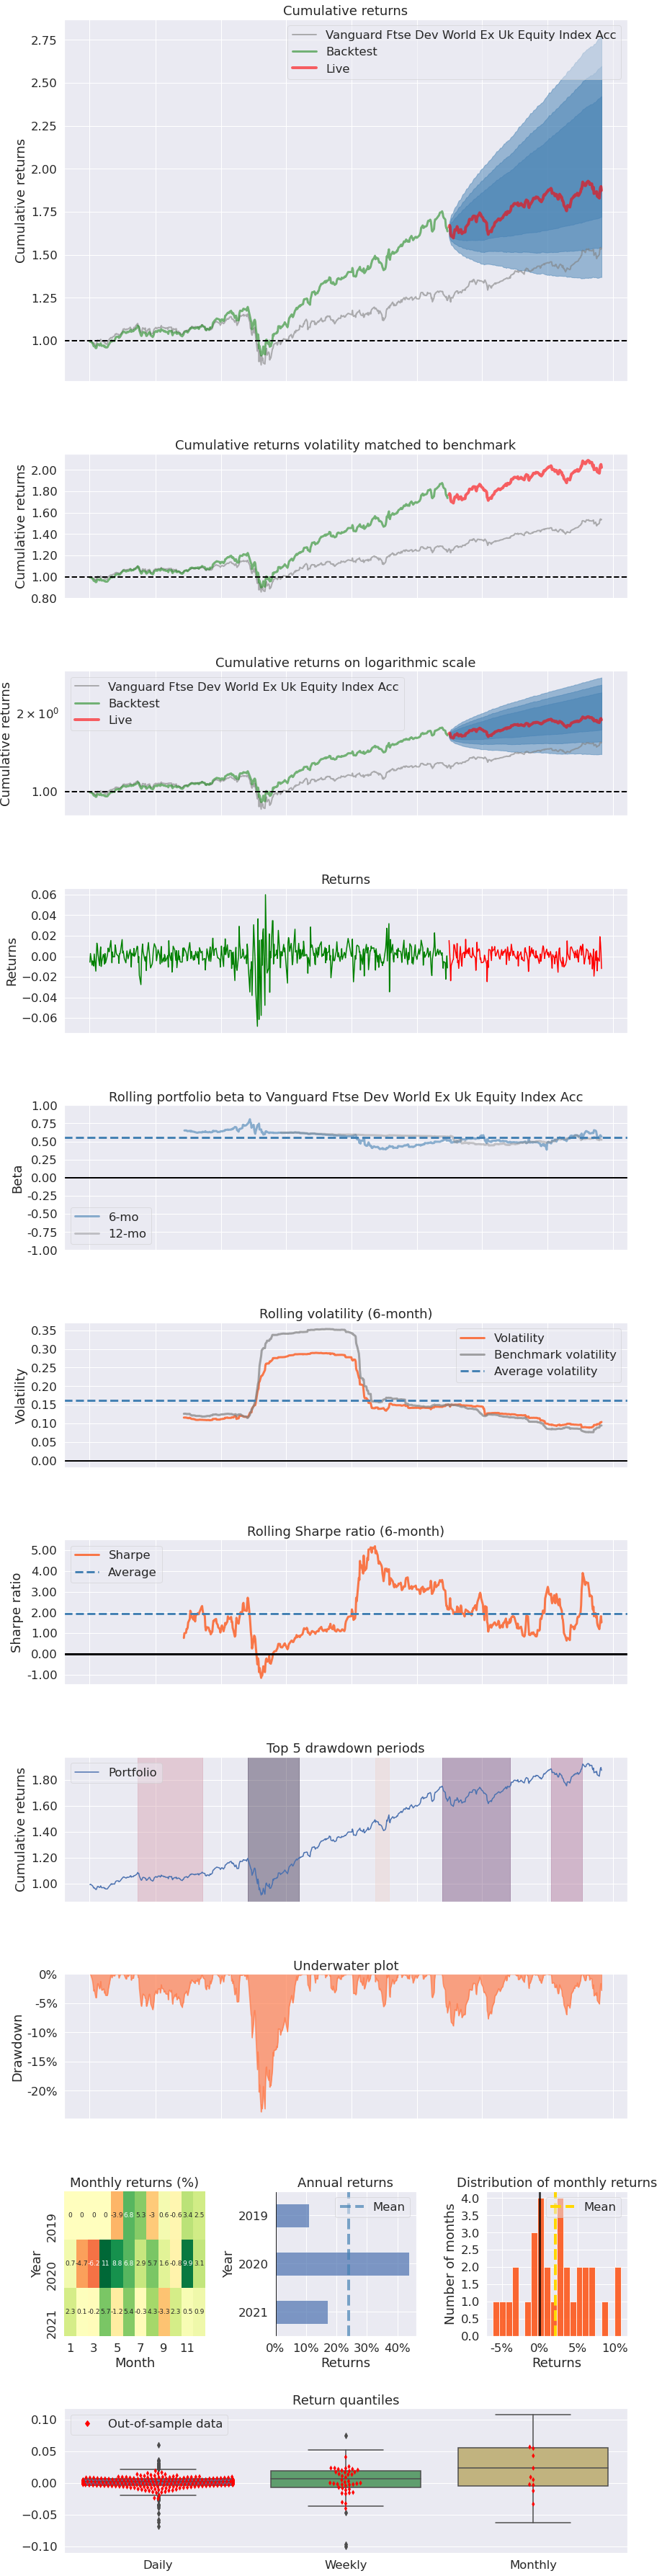

In [60]:
pf.create_returns_tear_sheet(rets["portfolio_HRP"],benchmark_rets=rets['Vanguard Ftse Dev World Ex Uk Equity Index Acc'],
                             live_start_date='2021-03-01', return_fig=False)

In [52]:
# monthly performance of HRP portfolio 
perf[0].display_monthly_returns()

  Year    Jan    Feb    Mar    Apr    May    Jun    Jul    Aug    Sep    Oct    Nov    Dec     YTD
------  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  ------
  2019   0      0      0      0     -1.71   7.7    7.15  -3.77   -9.4   0.12   7.89  -1.14    5.62
  2020  10.29  -5.56  -2.66  20.18  13.85  11      8.18  11.46    1.3   0.86  12.25   4.13  121.73
  2021   6.47  -3.38  -8.82  10.39  -6.65  16.34  -1.85   0.9    -5.9   3.93   1.01  -7.2     2.09


In [53]:
# monthly performance of min Var  
perf[1].display_monthly_returns()

  Year    Jan    Feb    Mar    Apr    May    Jun    Jul    Aug    Sep    Oct    Nov    Dec    YTD
------  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----
  2019   0      0      0      0     -1.84   8.82   4.36  -4.81  -1.77   0.27   5.45   5.85  16.66
  2020  -1.33  -7.48  -4.51   8.84  15.56   4.71   5.17   3.79   3.98  -2.11   8.89   3.14  43.24
  2021  -1.94  -0.86   0.09   7.79   0.67   3.01   2.67   5.73  -7.35   2.55  -1     -1.5    9.38


In [54]:
# monthly perfomance of Vanguard Developed 
perf[2].display_monthly_returns()

  Year    Jan    Feb    Mar    Apr    May    Jun    Jul    Aug    Sep    Oct    Nov    Dec    YTD
------  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----
  2019   0      0      0      0     -1.86   6.45   5.13  -2.38   1.03  -1.4    1.74   1.33  10.11
  2020  -0.06  -6.94  -6.65   5.97   6.11   4.16   2.09   2.04   1.9   -3.94   7.89   2.4   14.55
  2021   0.16  -2.12   3.06   5.56   0.06   3.51   1.04   3.42  -3.07   1.17   2.75   3.84  20.77


<AxesSubplot:title={'center':'Baillie Gifford American Fund B Accumulation Return Histogram'}, ylabel='Density'>

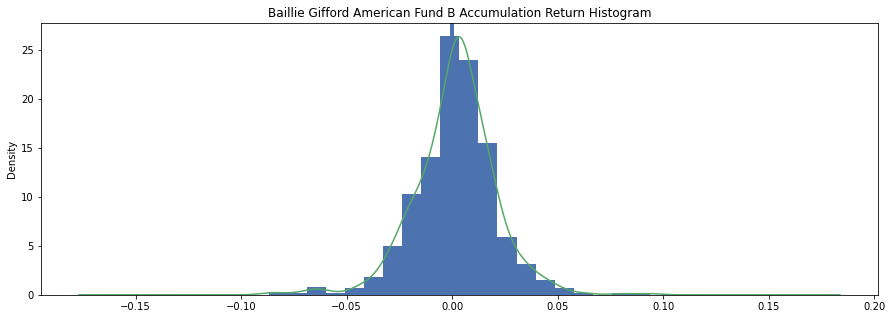

In [55]:
perf[0].plot_histogram()

In [63]:
# Ulcer index (bad volatility against returns)
# Martin advises against sampling less often than weekly though
ffn.core.to_ulcer_performance_index(price_index[price_index.index>="2020-11-01"], rf=0.0, nperiods=None).sort_values(ascending=False)

Vanguard Ftse Dev World Ex Uk Equity Index Acc              1.312743
Fidelity Funds - Global Technology Fund W-acc-gbp           1.158024
Baillie Gifford Global Income Growth Fund B Accumulation    0.805409
portfolio_HRP                                               0.552019
portfolio_min_vol                                           0.484513
Baillie Gifford European Fund B Accumulation                0.303359
Baillie Gifford Positive Change Fund B Accumulation         0.242148
Baillie Gifford Pacific B Acc                               0.169320
Baillie Gifford American Fund B Accumulation                0.139847
dtype: float64